In [ ]:
import torch 
import torchvision
import torch.nn as nn
import numpy as np
import torchvision.transforms as transforms

In [ ]:
x = torch.ones(2, 2, requires_grad=True)
print(x)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


In [ ]:
y = x + 2
print(y)

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [ ]:
print(y.grad_fn)

In [ ]:
z = y * y * 3
out = z.mean()

In [ ]:
print(z)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>)


In [ ]:
print(out)

tensor(27., grad_fn=<MeanBackward0>)


In [ ]:
out.backward()

In [ ]:
print(x.grad)  # d(out)/dx

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


To convince you:

$y = x + 2$

$z = y * y * 3$ 

$z_i = 3 (x_i + 2)^2$

Let's call $out$ tensor "$o$".

$o = \frac{1}{4} \sum_i z_i$ 

and

$z_i |_{x_i = 1} = 27$


So:


$\frac{\partial{o}}{\partial{x_i}} = \frac{3}{2} (x_i + 2)$

and

$\frac{\partial{o}}{\partial{x_i}} |_{x_i = 1} = \frac{9}{2} = 4.5$



In [ ]:
x = torch.tensor(1., requires_grad=True)
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)

In [ ]:
y = w * x + b 

In [ ]:
y

tensor(5., grad_fn=<AddBackward0>)

In [ ]:
y.backward()

In [ ]:
x.grad

tensor(2.)

In [ ]:
w.grad

tensor(1.)

In [ ]:
b.grad

tensor(1.)

In [ ]:
x = torch.randn(10, 3)
y = torch.randn(10, 2)

# Build a fully connected layer.
linear = nn.Linear(3, 2)
print ('w: ', linear.weight)
print ('b: ', linear.bias)

# Build loss function and optimizer.
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)

# Forward pass.
pred = linear(x)

# Compute loss.
loss = criterion(pred, y)
print('loss: ', loss.item())

# Backward pass.
loss.backward()

# Print out the gradients.
print ('dL/dw: ', linear.weight.grad) 
print ('dL/db: ', linear.bias.grad)

# 1-step gradient descent.
optimizer.step()

# You can also perform gradient descent at the low level.
# linear.weight.data.sub_(0.01 * linear.weight.grad.data)
# linear.bias.data.sub_(0.01 * linear.bias.grad.data)

# Print out the loss after 1-step gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('loss after 1 step optimization: ', loss.item())

w:  Parameter containing:
tensor([[ 0.3266, -0.4233,  0.5294],
        [ 0.5018,  0.4716, -0.1987]], requires_grad=True)
b:  Parameter containing:
tensor([-0.3547,  0.1009], requires_grad=True)
loss:  1.5855586528778076
dL/dw:  tensor([[ 0.4943, -1.1881,  1.0920],
        [ 0.2526, -0.1102, -0.4700]])
dL/db:  tensor([-0.2024,  0.1762])
loss after 1 step optimization:  1.5536723136901855


Epoch [5/60], Loss: 25.2519
Epoch [10/60], Loss: 10.4822
Epoch [15/60], Loss: 4.4984
Epoch [20/60], Loss: 2.0738
Epoch [25/60], Loss: 1.0912
Epoch [30/60], Loss: 0.6928
Epoch [35/60], Loss: 0.5310
Epoch [40/60], Loss: 0.4650
Epoch [45/60], Loss: 0.4379
Epoch [50/60], Loss: 0.4266
Epoch [55/60], Loss: 0.4216
Epoch [60/60], Loss: 0.4192


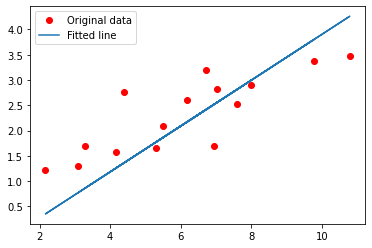

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# Hyper-parameters
input_size = 1
output_size = 1
num_epochs = 60
learning_rate = 0.001

# Toy dataset
x_train = np.array([[3.3], [4.4], [5.5], [6.71], [6.93], [4.168], 
                    [9.779], [6.182], [7.59], [2.167], [7.042], 
                    [10.791], [5.313], [7.997], [3.1]], dtype=np.float32)

y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573], 
                    [3.366], [2.596], [2.53], [1.221], [2.827], 
                    [3.465], [1.65], [2.904], [1.3]], dtype=np.float32)

# Linear regression model
model = nn.Linear(input_size, output_size)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

# Train the model
for epoch in range(num_epochs):
    # Convert numpy arrays to torch tensors
    inputs = torch.from_numpy(x_train)
    targets = torch.from_numpy(y_train)

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 5 == 0:
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

# Plot the graph
predicted = model(torch.from_numpy(x_train)).detach().numpy()
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, predicted, label='Fitted line')
plt.legend()
plt.show()

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

In [ ]:
input_size = 28 * 28    # 784
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

# MNIST dataset (images and labels)
train_dataset = torchvision.datasets.MNIST(root='../../data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='../../data', 
                                          train=False, 
                                          transform=transforms.ToTensor())

# Data loader (input pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

Extracting ../../data/MNIST/raw/train-images-idx3-ubyte.gz to ../../data/MNIST/raw


Extracting ../../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../../data/MNIST/raw



Extracting ../../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../../data/MNIST/raw


Extracting ../../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../../data/MNIST/raw
Processing...
Done!


/usr/local/lib/python3.6/dist-packages/torchvision/datasets/mnist.py:480: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /pytorch/torch/csrc/utils/tensor_numpy.cpp:141.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [ ]:
model = nn.Linear(input_size, num_classes)

# Loss and optimizer
# nn.CrossEntropyLoss() computes softmax internally
criterion = nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Reshape images to (batch_size, input_size)
        images = images.reshape(-1, input_size)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

# Test the model
# In test phase, we don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, input_size)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()

    print('Accuracy of the model on the 10000 test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Epoch [1/5], Step [100/600], Loss: 2.2807
Epoch [1/5], Step [200/600], Loss: 2.1427
Epoch [1/5], Step [300/600], Loss: 2.0419
Epoch [1/5], Step [400/600], Loss: 2.0164
Epoch [1/5], Step [500/600], Loss: 1.8606
Epoch [1/5], Step [600/600], Loss: 1.8120
Epoch [2/5], Step [100/600], Loss: 1.7538
Epoch [2/5], Step [200/600], Loss: 1.6535
Epoch [2/5], Step [300/600], Loss: 1.6001
Epoch [2/5], Step [400/600], Loss: 1.5349
Epoch [2/5], Step [500/600], Loss: 1.5217
Epoch [2/5], Step [600/600], Loss: 1.4936
Epoch [3/5], Step [100/600], Loss: 1.4588
Epoch [3/5], Step [200/600], Loss: 1.4206
Epoch [3/5], Step [300/600], Loss: 1.3011
Epoch [3/5], Step [400/600], Loss: 1.2659
Epoch [3/5], Step [500/600], Loss: 1.2779
Epoch [3/5], Step [600/600], Loss: 1.2629
Epoch [4/5], Step [100/600], Loss: 1.2126
Epoch [4/5], Step [200/600], Loss: 1.0773
Epoch [4/5], Step [300/600], Loss: 1.2026
Epoch [4/5], Step [400/600], Loss: 1.1045
Epoch [4/5], Step [500/600], Loss: 1.1030
Epoch [4/5], Step [600/600], Loss: